In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from collections import Counter

# 1.Train Test split

In [2]:
df = pd.read_csv('../data/processed/featured/features.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Total rows: 2791
Date range: 2015-02-20 00:00:00 to 2026-03-27 00:00:00


In [3]:
drop_cols = [
    'Date',
    # ไม่ใช้เพราะ non-stationary
    'gold_close', 'gold_open', 'gold_high', 'gold_low', 'gold_vol',
    'dxy_close', 'vix_close', 'yield_close', 'sp500_close', 'oil_close',
    # Targets
    'return_tomorrow', 'direction'
]

feature_cols = [c for c in df.columns if c not in drop_cols]
print(f"Features ทั้งหมด: {len(feature_cols)}")
print(feature_cols)

X = df[feature_cols]
y_clf = df['direction']       # Classification: -1, 0, 1
y_reg = df['return_tomorrow'] # Regression: % return

Features ทั้งหมด: 30
['gold_close_pct', 'dxy_close_pct', 'vix_close_pct', 'yield_close_pct', 'sp500_close_pct', 'oil_close_pct', 'gold_close_pct_lag1', 'gold_close_pct_lag5', 'gold_close_pct_lag10', 'dxy_close_pct_lag1', 'dxy_close_pct_lag5', 'dxy_close_pct_lag10', 'vix_close_pct_lag1', 'vix_close_pct_lag5', 'vix_close_pct_lag10', 'yield_close_pct_lag1', 'yield_close_pct_lag5', 'yield_close_pct_lag10', 'sp500_close_pct_lag1', 'sp500_close_pct_lag5', 'sp500_close_pct_lag10', 'oil_close_pct_lag1', 'oil_close_pct_lag5', 'oil_close_pct_lag10', 'gold_rsi', 'gold_macd', 'gold_macd_diff', 'gold_bb_pband', 'gold_atr', 'gold_vol_log']


In [4]:
n = len(df)
train_end  = int(n*0.7)
val_end    = int(n*0.85)

# Train:70% Validation:15% Test:15%
X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

In [5]:
y_clf_train = y_clf.iloc[:train_end]
y_clf_val   = y_clf.iloc[train_end:val_end]
y_clf_test  = y_clf.iloc[val_end:]

In [6]:
y_reg_train = y_reg.iloc[:train_end]
y_reg_val   = y_reg.iloc[train_end:val_end]
y_reg_test  = y_reg.iloc[val_end:]

In [7]:
print(f"\nTrain : {df['Date'].iloc[0].date()} → {df['Date'].iloc[train_end-1].date()} ({train_end} rows)")
print(f"Val   : {df['Date'].iloc[train_end].date()} → {df['Date'].iloc[val_end-1].date()} ({val_end - train_end} rows)")
print(f"Test  : {df['Date'].iloc[val_end].date()} → {df['Date'].iloc[-1].date()} ({n - val_end} rows)")


Train : 2015-02-20 → 2022-11-23 (1953 rows)
Val   : 2022-11-25 → 2024-07-29 (419 rows)
Test  : 2024-07-30 → 2026-03-27 (419 rows)


# 2.Feature Selection

2.1 Feature Importance ด้วย Random Forest


Top 20 Features:
                  feature  importance
0                gold_atr    0.049003
1         yield_close_pct    0.043513
2      oil_close_pct_lag1    0.039292
3    yield_close_pct_lag5    0.037060
4   sp500_close_pct_lag10    0.035616
5            gold_vol_log    0.035200
6     oil_close_pct_lag10    0.034740
7    sp500_close_pct_lag5    0.034480
8         sp500_close_pct    0.034298
9      oil_close_pct_lag5    0.034102
10  yield_close_pct_lag10    0.034047
11     dxy_close_pct_lag1    0.033696
12    dxy_close_pct_lag10    0.033267
13     vix_close_pct_lag5    0.033010
14          vix_close_pct    0.032940
15         gold_close_pct    0.032853
16               gold_rsi    0.032605
17   yield_close_pct_lag1    0.031797
18    vix_close_pct_lag10    0.031418
19    gold_close_pct_lag5    0.031114


C:\Users\ppkls\AppData\Local\Temp\ipykernel_5192\961669543.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


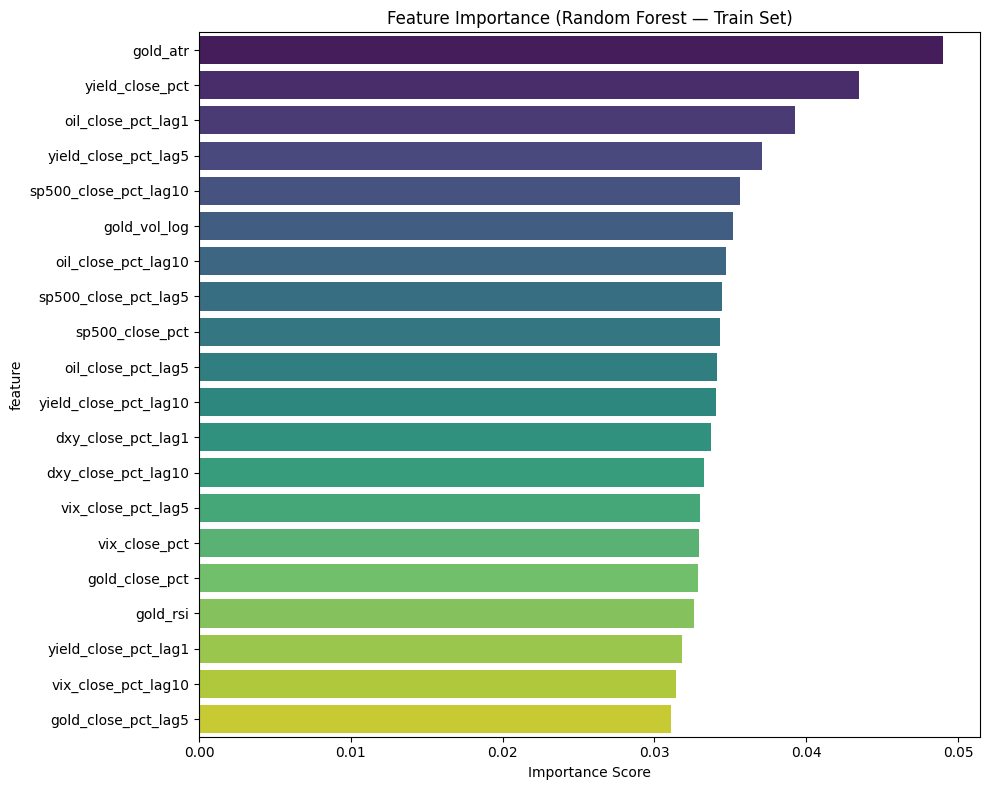

In [8]:
rf_selector = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_train, y_clf_train)

importance_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 20 Features:")
print(importance_df.head(20))

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20),
    x='importance', y='feature',
    palette='viridis'
)
plt.title('Feature Importance (Random Forest — Train Set)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

2.2 เลือก Top Features

In [9]:
# เลือก features ที่ cumulative importance ถึง 95%
importance_df['cumulative'] = importance_df['importance'].cumsum()

top_features = importance_df[
    importance_df['cumulative'] <= 0.95
]['feature'].tolist()

# ให้มีอย่างน้อย 10 ตัว และไม่เกิน 20 ตัว
if len(top_features) < 10:
    top_features = importance_df['feature'].head(10).tolist()
if len(top_features) > 20:
    top_features = importance_df['feature'].head(20).tolist()

print(f"\nSelected Features: {len(top_features)}:")
print(top_features)

# Apply selection
X_train_sel = X_train[top_features]
X_val_sel   = X_val[top_features]
X_test_sel  = X_test[top_features]


Selected Features: 20:
['gold_atr', 'yield_close_pct', 'oil_close_pct_lag1', 'yield_close_pct_lag5', 'sp500_close_pct_lag10', 'gold_vol_log', 'oil_close_pct_lag10', 'sp500_close_pct_lag5', 'sp500_close_pct', 'oil_close_pct_lag5', 'yield_close_pct_lag10', 'dxy_close_pct_lag1', 'dxy_close_pct_lag10', 'vix_close_pct_lag5', 'vix_close_pct', 'gold_close_pct', 'gold_rsi', 'yield_close_pct_lag1', 'vix_close_pct_lag10', 'gold_close_pct_lag5']


# 3.Handle Class Imbalance

3.1 เช็ค Class Distribution

In [10]:
counts = y_clf_train.value_counts().sort_index()
ratios = y_clf_train.value_counts(normalize=True).sort_index() * 100

print("Class Distribution (Train Set)")
for cls, label in {-1:'Down', 0:'Side', 1:'Up'}.items():
    c = counts.get(cls, 0)
    r = ratios.get(cls, 0)
    print(f"  {label:>5} ({cls:>2}): {c:>5} rows  ({r:.1f}%)")

majority = ratios.max()
minority = ratios.min()
imbalance_ratio = majority / minority
print(f"\nImbalance Ratio: {imbalance_ratio:.2f} : 1")

Class Distribution (Train Set)
   Down (-1):   433 rows  (22.2%)
   Side ( 0):  1030 rows  (52.7%)
     Up ( 1):   490 rows  (25.1%)

Imbalance Ratio: 2.38 : 1


3.2 ตัดสินใจว่าต้องแก้ไหม

Mild Imbalance


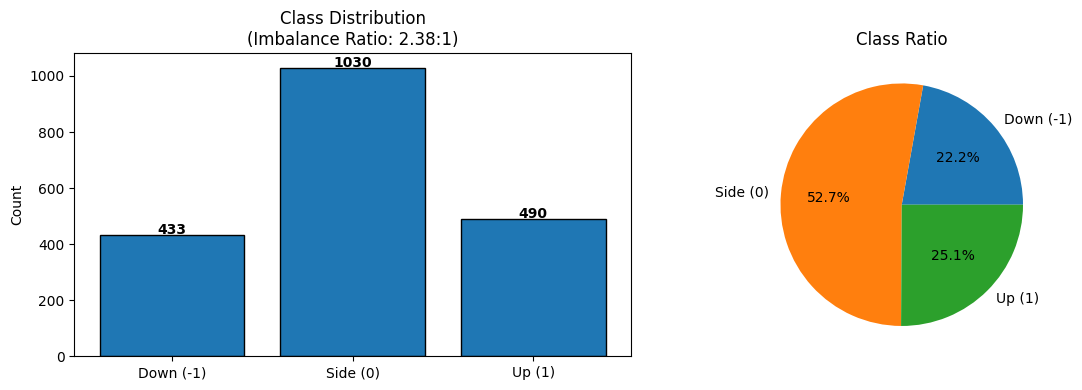

In [11]:
if imbalance_ratio < 1.5:
    print("Balanced")
    strategy = 'none'
elif imbalance_ratio < 3.0:
    print("Mild Imbalance")
else:
    print("Severe Imbalance")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Down (-1)', 'Side (0)', 'Up (1)']
values = [counts.get(-1,0), counts.get(0,0), counts.get(1,0)]

axes[0].bar(labels, values, edgecolor='black')
axes[0].set_title(f'Class Distribution\n(Imbalance Ratio: {imbalance_ratio:.2f}:1)')
axes[0].set_ylabel('Count')
for i, v in enumerate(values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

axes[1].pie(values, labels=labels, autopct='%1.1f%%')
axes[1].set_title('Class Ratio')
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150)
plt.show()

3.3 Save file

In [14]:
import os
os.makedirs('../data/processed/splits', exist_ok=True)

X_train_sel.to_csv('../data/processed/splits/X_train.csv', index=False)
X_val_sel.to_csv('../data/processed/splits/X_val.csv',   index=False)
X_test_sel.to_csv('../data/processed/splits/X_test.csv',  index=False)

y_clf_train.to_csv('../data/processed/splits/y_clf_train.csv', index=False)
y_clf_val.to_csv('../data/processed/splits/y_clf_val.csv',   index=False)
y_clf_test.to_csv('../data/processed/splits/y_clf_test.csv',  index=False)

y_reg_train.to_csv('../data/processed/splits/y_reg_train.csv', index=False)
y_reg_val.to_csv('../data/processed/splits/y_reg_val.csv',   index=False)
y_reg_test.to_csv('../data/processed/splits/y_reg_test.csv',  index=False)

print(f"""
X_train : {X_train_sel.shape}
X_val   : {X_val_sel.shape}
X_test  : {X_test_sel.shape}
Features: {top_features}
""")


X_train : (1953, 20)
X_val   : (419, 20)
X_test  : (419, 20)
Features: ['gold_atr', 'yield_close_pct', 'oil_close_pct_lag1', 'yield_close_pct_lag5', 'sp500_close_pct_lag10', 'gold_vol_log', 'oil_close_pct_lag10', 'sp500_close_pct_lag5', 'sp500_close_pct', 'oil_close_pct_lag5', 'yield_close_pct_lag10', 'dxy_close_pct_lag1', 'dxy_close_pct_lag10', 'vix_close_pct_lag5', 'vix_close_pct', 'gold_close_pct', 'gold_rsi', 'yield_close_pct_lag1', 'vix_close_pct_lag10', 'gold_close_pct_lag5']

